**1. Montage Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**2. Vérification du dataset**

In [ ]:
import os
base = "/content/drive/MyDrive/LicensePlate_YOLO"
print(os.listdir(base))

['valid', 'test', 'train', 'data.yaml']


In [ ]:
base = "/content/drive/MyDrive/LicensePlate_YOLO"

for split in ["train", "valid", "test"]:
    images_path = os.path.join(base, split, "images") #join () rassemble toutes les images indiv en une seule chaine de caracteres + split() ykassamhom kol image w esmha s kol
    labels_path = os.path.join(base, split, "labels")

    images = os.listdir(images_path)
    labels = os.listdir(labels_path)

    print("------", split, "------")
    print("Images :", len(images))
    print("Labels :", len(labels))

------ train ------
Images : 24
Labels : 24
------ valid ------
Images : 7
Labels : 7
------ test ------
Images : 2
Labels : 2


In [ ]:
labels_path = "/content/drive/MyDrive/LicensePlate_YOLO/train/labels"

classes = set() #ensble feragh

for file in os.listdir(labels_path):
    if file.endswith(".txt"): #bech nchoufou ken labels mtaa les images
        with open(os.path.join(labels_path,file)) as f:
            for line in f:
                classes.add(int(line.split()[0]))

print(sorted(classes))


#--------------------------------- 2ème code pour verifier ---------------------------------
# base = "/content/drive/MyDrive/LicensePlate_YOLO"

# classes = set()

# for split in ["train", "valid", "test"]:
#     labels_path = os.path.join(base, split, "labels")

#     for file in os.listdir(labels_path):
#         if file.endswith(".txt"):
#             with open(os.path.join(labels_path, file)) as f:
#                 for line in f:
#                     classes.add(int(line.split()[0]))

# print("Classes trouvées :", sorted(classes))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


**3. Installation de YOLOv8+training**

In [ ]:
!pip install -q ultralytics

In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/drive/MyDrive/LicensePlate_YOLO/data.yaml",
    epochs=100,
    imgsz=640,
    batch=8,
    project="/content/drive/MyDrive/YOLO_Results",
    name="license_plate_characters"
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/LicensePlate_YOLO/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=license_pla

**4. Evaluation**

In [ ]:
#Regarder les performances globales

model = YOLO("/content/drive/MyDrive/YOLO_Results/license_plate_characters-3/weights/best.pt")
metrics = model.val(
    data="/content/drive/MyDrive/LicensePlate_YOLO/data.yaml"
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.9±0.9 ms, read: 1.3±0.8 MB/s, size: 2.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/LicensePlate_YOLO/valid/labels.cache... 7 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7/7 1.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 8.4it/s 0.1s
                   all          7         33      0.572      0.642      0.586      0.506
                    TN          7          7      0.802          1      0.995      0.808
                     0          3          3      0.606          1      0.913      0.913
                     1          5          8      0.705      

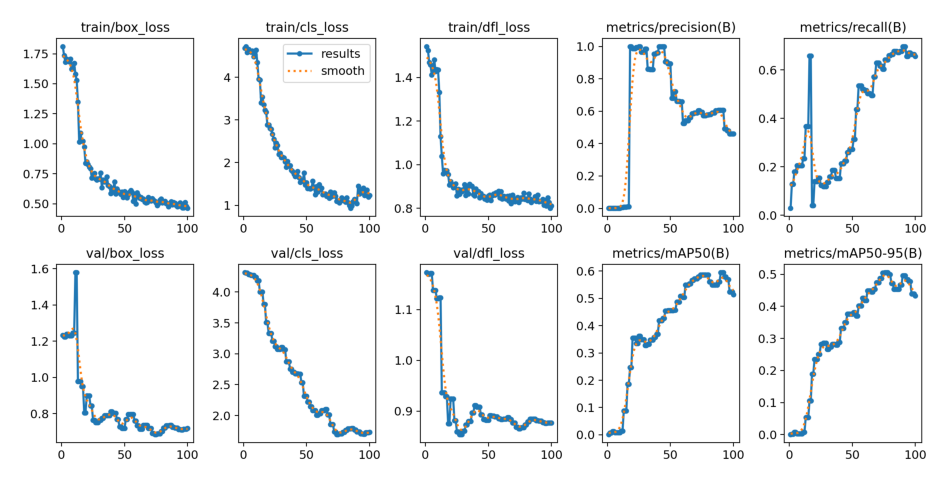

In [ ]:
import matplotlib.pyplot as plt
import cv2

results_path = "/content/drive/MyDrive/YOLO_Results/license_plate_characters-3/results.png"

img = cv2.imread(results_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
#Tester sur les images de test -la premiere fois où le res va etre stocké dans /content/runs/detect/predict-2 et non pas predict-3
from ultralytics import YOLO
model = YOLO("/content/drive/MyDrive/YOLO_Results/license_plate_characters-3/weights/best.pt")

results = model.predict(
    source="/content/drive/MyDrive/LicensePlate_YOLO/test/images",
    save=True,
    conf=0.25
)


image 1/2 /content/drive/MyDrive/LicensePlate_YOLO/test/images/1085_jpg.rf.1dd71234b9fb36c517c4b8f3e007c956_plate_0.jpg: 192x640 1 TN, 1 0, 2 1s, 1 5, 1 6, 1 7, 10.8ms
image 2/2 /content/drive/MyDrive/LicensePlate_YOLO/test/images/1096_jpg.rf.b62dd05f867d4a607831e3306c20ca58_plate_0.jpg: 192x640 1 TN, 2 0s, 1 1, 3 7s, 6.3ms
Speed: 1.2ms preprocess, 8.5ms inference, 1.5ms postprocess per image at shape (1, 3, 192, 640)
Results saved to /content/runs/detect/predict-2


**---------> LES CELLULES CONSACREES A Best.pt**

In [ ]:
#Charger le meilleur modèle :best.pt
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/YOLO_Results/license_plate_characters-3/weights/best.pt")

In [ ]:
#Calculer les métriques sur le jeu de validation
metrics = model.val(
    data="/content/drive/MyDrive/LicensePlate_YOLO/data.yaml"
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.3±0.1 ms, read: 5.1±2.7 MB/s, size: 4.1 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/LicensePlate_YOLO/valid/labels.cache... 7 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7/7 1.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 9.4it/s 0.1s
                   all          7         33      0.572      0.642      0.586      0.506
                    TN          7          7      0.802          1      0.995      0.808
                     0          3          3      0.606          1      0.913      0.913
                     1          5          8      0.705      

**5. Prédicitions**

In [ ]:
#1- Faire des prédictions sur le jeu de test

results = model.predict(
    source="/content/drive/MyDrive/LicensePlate_YOLO/test/images",
    conf=0.25,
    save=True)


image 1/2 /content/drive/MyDrive/LicensePlate_YOLO/test/images/1085_jpg.rf.1dd71234b9fb36c517c4b8f3e007c956_plate_0.jpg: 192x640 1 TN, 1 0, 2 1s, 1 5, 1 6, 1 7, 8.3ms
image 2/2 /content/drive/MyDrive/LicensePlate_YOLO/test/images/1096_jpg.rf.b62dd05f867d4a607831e3306c20ca58_plate_0.jpg: 192x640 1 TN, 2 0s, 1 1, 3 7s, 7.8ms
Speed: 1.4ms preprocess, 8.0ms inference, 1.3ms postprocess per image at shape (1, 3, 192, 640)
Results saved to /content/runs/detect/predict-3


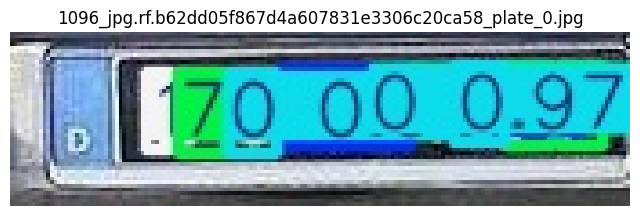

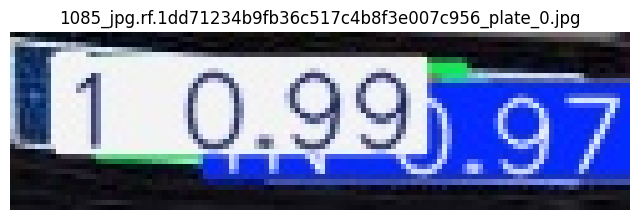

In [ ]:
#2- Afficher les résultats des prédictions du jeu de test(de la cellule precedente)-> ces res sont enregistres dans runs/detect/predict/

import os
import cv2
import matplotlib.pyplot as plt

pred_folder = "/content/runs/detect/predict"

for img_name in os.listdir(pred_folder):
    img_path = os.path.join(pred_folder, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.title(img_name)
    plt.axis("off")
    plt.show()

In [ ]:
#3- Afficher les coordonnées et les classes détectées (pour voir ce que le modèle détecte exactement) :

for r in results:
    print("Image :", r.path)

    for box in r.boxes:
        cls = int(box.cls)
        conf = float(box.conf)

        print(f"Classe : {model.names[cls]} | Confiance : {conf:.3f}")

Image : /content/drive/MyDrive/LicensePlate_YOLO/test/images/1085_jpg.rf.1dd71234b9fb36c517c4b8f3e007c956_plate_0.jpg
Classe : 1 | Confiance : 0.989
Classe : TN | Confiance : 0.974
Classe : 5 | Confiance : 0.965
Classe : 6 | Confiance : 0.954
Classe : 0 | Confiance : 0.867
Classe : 7 | Confiance : 0.545
Classe : 1 | Confiance : 0.411
Image : /content/drive/MyDrive/LicensePlate_YOLO/test/images/1096_jpg.rf.b62dd05f867d4a607831e3306c20ca58_plate_0.jpg
Classe : 0 | Confiance : 0.971
Classe : 0 | Confiance : 0.960
Classe : TN | Confiance : 0.931
Classe : 7 | Confiance : 0.895
Classe : 7 | Confiance : 0.855
Classe : 7 | Confiance : 0.832
Classe : 1 | Confiance : 0.614


In [ ]:
#4- Afficher les bounding boxes en détail (Pour chaque caractère)

for r in results:
    print("\nImage :", r.path)

    for box in r.boxes:
        print("-------------------")
        print("Classe :", model.names[int(box.cls)])
        print("Confiance :", float(box.conf))
        print("Coordonnées :", box.xyxy.cpu().numpy())


Image : /content/drive/MyDrive/LicensePlate_YOLO/test/images/1085_jpg.rf.1dd71234b9fb36c517c4b8f3e007c956_plate_0.jpg
-------------------
Classe : 1
Confiance : 0.9891878962516785
Coordonnées : [[     9.7919      5.5772       14.26      21.253]]
-------------------
Classe : TN
Confiance : 0.9743421077728271
Coordonnées : [[     40.128      10.545      60.735      23.477]]
-------------------
Classe : 5
Confiance : 0.9647508263587952
Coordonnées : [[     75.439      10.697      83.402      26.352]]
-------------------
Classe : 6
Confiance : 0.9536160826683044
Coordonnées : [[     65.763      10.099      73.398      25.674]]
-------------------
Classe : 0
Confiance : 0.8671488165855408
Coordonnées : [[     85.818      10.767      93.781      26.565]]
-------------------
Classe : 7
Confiance : 0.5454824566841125
Coordonnées : [[     17.693      6.1599      25.302      22.531]]
-------------------
Classe : 1
Confiance : 0.41135871410369873
Coordonnées : [[     17.656      6.3392      25.3

**6. Visualisation matrices de confusion +celle normalisee**

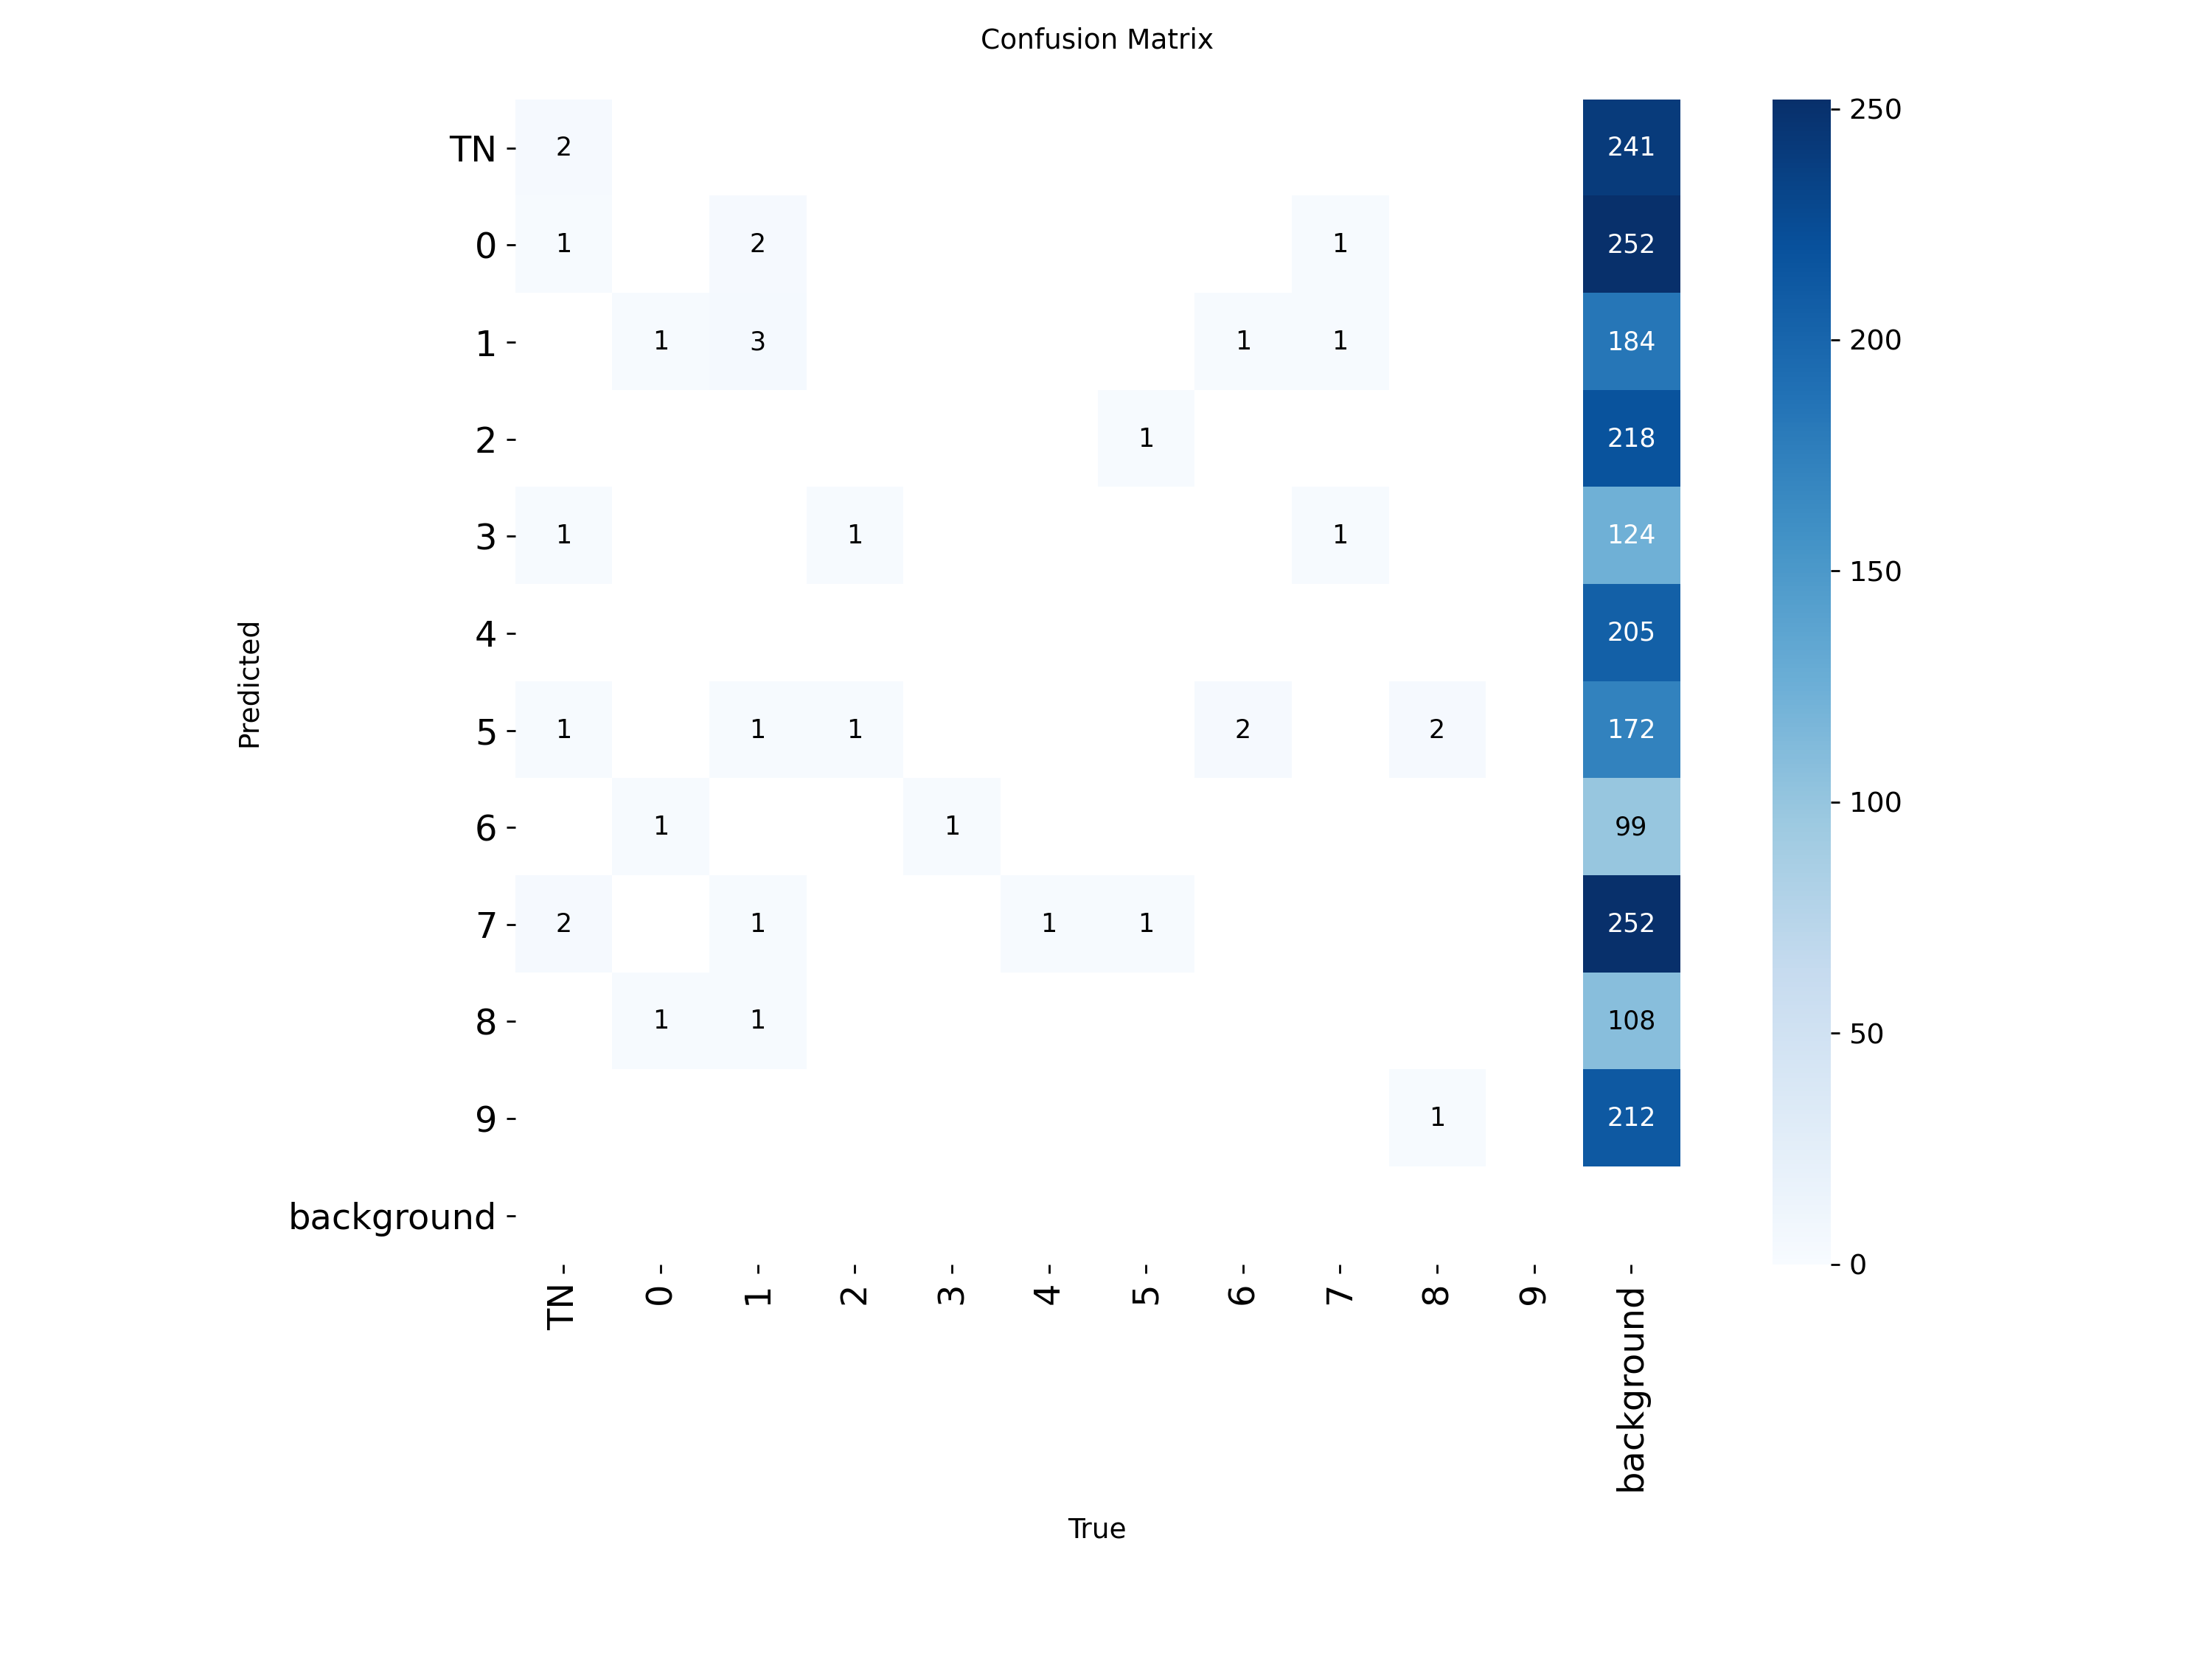

In [ ]:
from IPython.display import Image, display
display(Image("/content/runs/detect/val-3/confusion_matrix.png"))

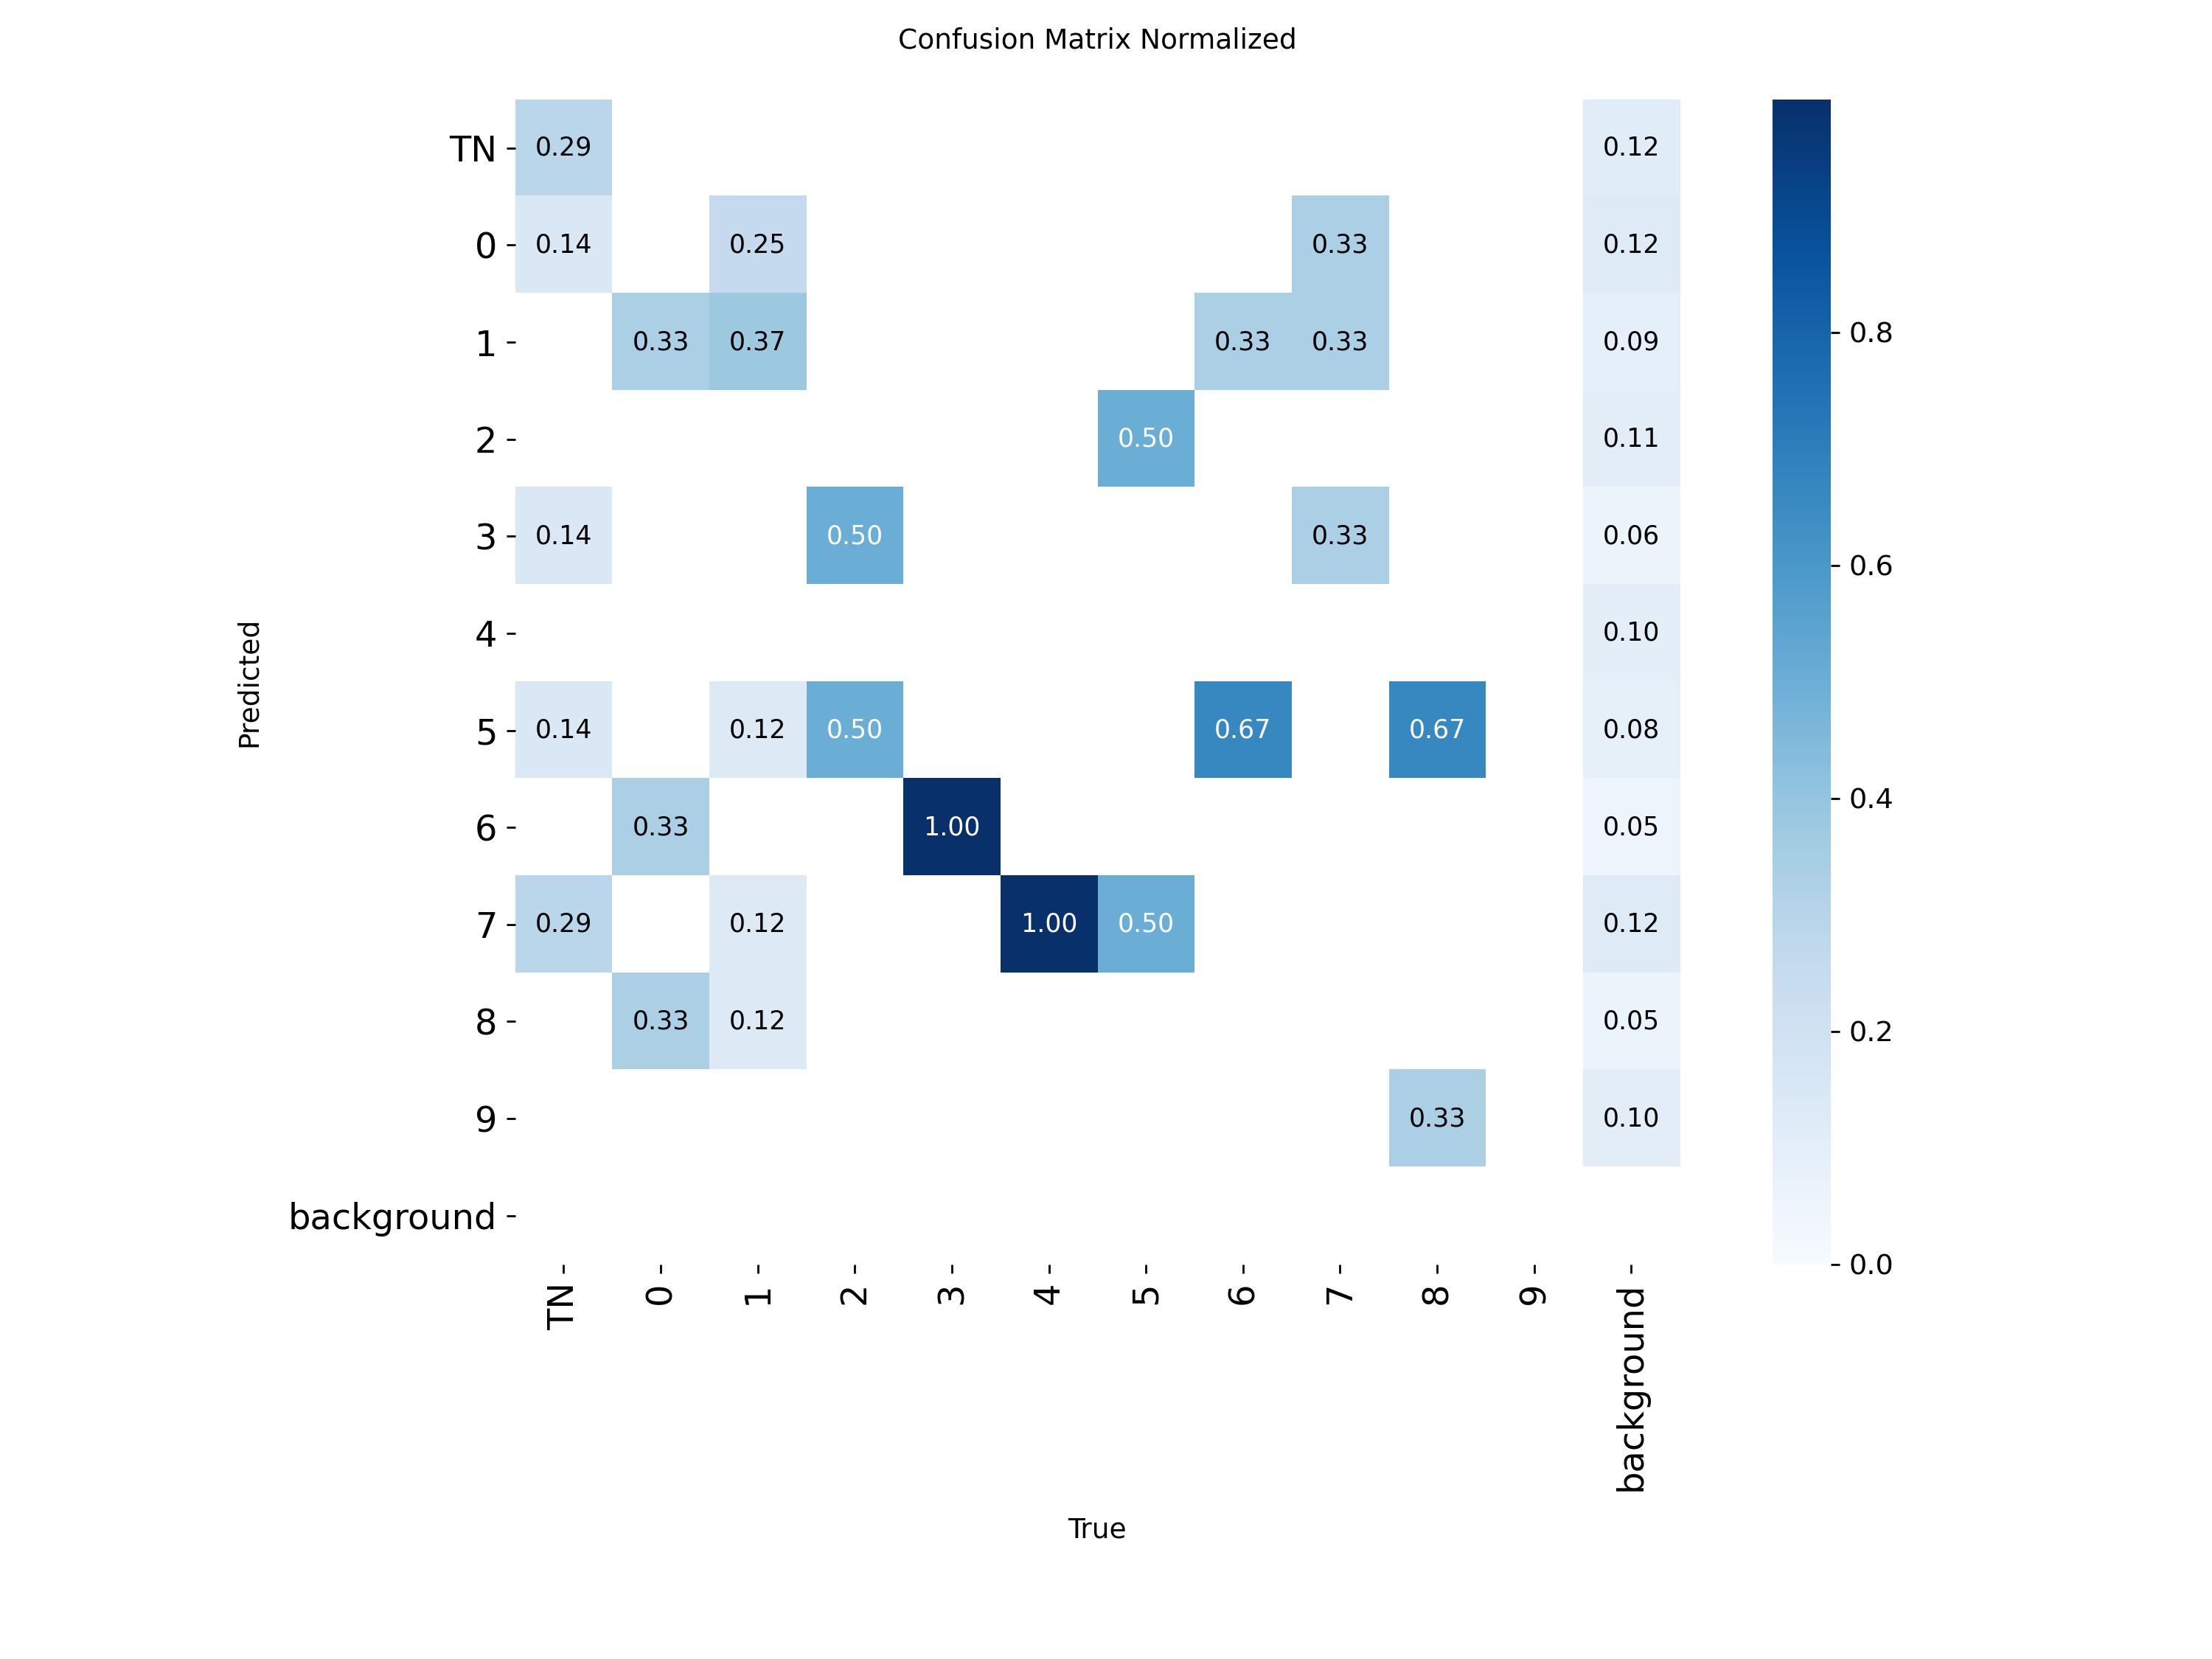

In [ ]:
from IPython.display import Image, display
display(Image("/content/runs/detect/val-3/confusion_matrix_normalized.png"))